In [1]:
import numpy as np

def fdm_explicit_call(S0, K, T, r, sigma, M, N):
    """
    명시적 유한차분법(Explicit FDM)을 이용한 유러피안 콜옵션 프라이싱
    
    S0: 현재 기초자산 가격
    K: 행사가격
    T: 잔존만기 (연율화, 예: 1년 = 1.0)
    r: 무위험 이자율
    sigma: 변동성
    M: 주가 격자 수 (Price steps)
    N: 시간 격자 수 (Time steps)
    """
    
    # 1. 격자(Grid) 세팅을 위한 변수 정의
    S_max = 2 * K  # 주가 최대치 (통상 행사가의 2배~3배로 설정)
    dS = S_max / M # 주가 한 칸의 간격
    dt = T / N     # 시간 한 칸의 간격
    
    # FDM 안정성 조건 확인 (Explicit FDM의 치명적 약점 방지)
    # 분산이 너무 커지면 계산이 폭발하므로, 격자 간격을 조정해야 할 수도 있습니다.
    
    # 2. 바둑판(Grid) 생성: 행(주가 M+1개) x 열(시간 N+1개)
    # V[i, j] 는 주가가 i*dS 이고 시간이 j*dt 일 때의 옵션 가격
    V = np.zeros((M + 1, N + 1))
    
    # 주가 배열 생성
    S = np.linspace(0, S_max, M + 1)
    
    # 3. 경계 조건(Boundary Conditions) 설정
    # (1) 만기 시점 (j = N): 콜옵션의 페이오프 Max(S - K, 0)
    V[:, N] = np.maximum(S - K, 0)
    
    # (2) 주가가 0일 때 (i = 0): 콜옵션 가치는 0
    V[0, :] = 0
    
    # (3) 주가가 S_max일 때 (i = M): 아주 깊은 내가격(Deep In-The-Money)
    # S가 충분히 크면 콜옵션 가치는 S - K * exp(-r * 남은시간) 으로 수렴
    for j in range(N + 1):
        V[M, j] = S_max - K * np.exp(-r * (T - j * dt))
        
    # 4. 역방향 스텝 계산 (시간을 만기에서부터 현재로 거슬러 올라감)
    # 미분방정식을 풀어서 나온 a, b, c 계수
    for j in range(N - 1, -1, -1):
        for i in range(1, M):
            a = 0.5 * dt * (sigma**2 * i**2 - r * i)
            b = 1 - dt * (sigma**2 * i**2 + r)
            c = 0.5 * dt * (sigma**2 * i**2 + r * i)
            
            # 다음 시간(j+1)의 위, 중간, 아래 세 점을 이용해 현재 시간(j)의 값을 도출
            V[i, j] = a * V[i - 1, j + 1] + b * V[i, j + 1] + c * V[i + 1, j + 1]
            
    # 5. 현재 주가(S0)에 가장 가까운 격자의 옵션 가격 찾기
    # 주가 S0가 위치한 인덱스를 찾아서 해당 값을 반환
    i_star = int(S0 / dS)
    return V[i_star, 0]

# --- 실행 및 테스트 ---
# 파라미터 세팅 (KOSPI 200 예시)
S0 = 360.0    # 현재 코스피200 지수
K = 360.0     # 등가격(ATM) 옵션
T = 30 / 365  # 만기 30일 남음
r = 0.035     # 국고채 금리 3.5%
sigma = 0.15  # 변동성 15%

# 격자(Grid) 해상도 세팅
# Explicit FDM은 dt가 dS^2 에 비해 충분히 작지 않으면 에러(발산)가 납니다.
# 시간(N)을 충분히 크게 주어야 합니다.
M_steps = 100
N_steps = 5000 

fdm_price = fdm_explicit_call(S0, K, T, r, sigma, M_steps, N_steps)
print(f"FDM으로 계산된 콜옵션 이론가: {fdm_price:.4f}")

FDM으로 계산된 콜옵션 이론가: 6.5228


In [3]:
!pip install scipy

  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl (36.5 MB)


In [4]:
import numpy as np
import scipy.linalg as linalg
from scipy.stats import norm

def fdm_crank_nicolson_call(S0, K, T, r, sigma, M, N):
    S_max = 2 * K
    dS = S_max / M
    dt = T / N
    
    # 주가 격자
    S = np.linspace(0, S_max, M + 1)
    
    # 계수 설정 (i = 1 부터 M-1 까지)
    i = np.arange(1, M)
    alpha = 0.25 * dt * (sigma**2 * i**2 - r * i)
    beta = -0.5 * dt * (sigma**2 * i**2 + r)
    gamma = 0.25 * dt * (sigma**2 * i**2 + r * i)
    
    # 삼중대각행렬(Tridiagonal Matrix) 세팅을 위한 대각 원소들
    # A * V_new = B * V_old 를 풀기 위한 행렬 M1(A), M2(B)
    M1 = np.diag(1 - beta) + np.diag(-alpha[1:], -1) + np.diag(-gamma[:-1], 1)
    M2 = np.diag(1 + beta) + np.diag(alpha[1:], -1) + np.diag(gamma[:-1], 1)
    
    # V 배열 초기화 및 만기 페이오프 (경계 조건)
    V = np.maximum(S - K, 0)
    
    # 역방향 스텝 계산 (행렬 방정식 풀이)
    for j in range(N - 1, -1, -1):
        # B * V_old 계산
        b_vec = M2.dot(V[1:M])
        
        # 경계 조건 반영 (주가 0, 주가 S_max 일 때)
        b_vec[0] += alpha[0] * (0 + 0) # S=0일 때 콜옵션 0
        b_vec[-1] += gamma[-1] * ((S_max - K * np.exp(-r * (T - j * dt))) + 
                                  (S_max - K * np.exp(-r * (T - (j+1) * dt))))
        
        # 선형 연립방정식 풀이: A * V_new = b_vec
        # linalg.solve는 빠르고 정확하게 행렬의 역산을 수행합니다.
        V[1:M] = linalg.solve(M1, b_vec)
        
        # 양 끝 경계값 업데이트
        V[0] = 0
        V[M] = S_max - K * np.exp(-r * (T - j * dt))
        
    # S0에 해당하는 위치의 값을 보간법(Interpolation)으로 더 정확히 추출
    return np.interp(S0, S, V)

# --- 비교용 블랙-숄즈 정답 함수 ---
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# --- 실행 및 오차 테스트 ---
S0, K, T, r, sigma = 360.0, 360.0, 30/365, 0.035, 0.15

# 블랙-숄즈 이론가 (이 값이 우리가 도달해야 할 절대 정답입니다)
bs_price = black_scholes_call(S0, K, T, r, sigma)

# 크랭크-니콜슨 FDM 계산 (M과 N을 명시적 방법보다 훨씬 적게 줘도 됩니다)
M_steps = 400  # 주가 격자
N_steps = 400  # 시간 격자 (Explicit에서는 5000 이상 주어야 했던 것을 줄임)

cn_price = fdm_crank_nicolson_call(S0, K, T, r, sigma, M_steps, N_steps)

print(f"블랙-숄즈 정답 : {bs_price:.6f}")
print(f"크랭크-니콜슨  : {cn_price:.6f}")
print(f"오차 (Difference): {abs(bs_price - cn_price):.6f}")

블랙-숄즈 정답 : 6.697661
크랭크-니콜슨  : 6.687198
오차 (Difference): 0.010463


In [5]:
import numpy as np
from scipy.stats import norm

# 1. 블랙-숄즈 콜옵션 가격 함수 (기존 엔진)
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# 2. 베가(Vega) 산출 함수: 변동성이 1% 변할 때 옵션 가격이 얼마나 변하는가 (미분값)
def bs_vega(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return S * np.sqrt(T) * norm.pdf(d1)

# 3. 뉴턴-랩슨 내재변동성 탐색 함수
def implied_volatility_call(market_price, S, K, T, r, tol=1e-6, max_iter=100):
    """
    market_price: 실제 시장에서 거래되는 옵션 가격
    tol: 허용 오차 (이 값이 작을수록 정확해짐)
    """
    # 변동성 초기값 추정 (보통 0.2 즉 20% 등 임의의 값으로 시작)
    sigma = 0.20 
    
    for i in range(max_iter):
        # 현재 추정된 변동성으로 이론가 계산
        price_diff = bs_call(S, K, T, r, sigma) - market_price
        
        # 오차가 허용치 이내로 들어오면 탐색 종료
        if abs(price_diff) < tol:
            return sigma
        
        # 베가(기울기) 계산
        vega = bs_vega(S, K, T, r, sigma)
        
        # 베가가 너무 작으면(0에 수렴) 탐색이 멈추므로 방어 로직 추가
        if vega < 1e-8:
            break
            
        # 뉴턴-랩슨 업데이트: 다음 변동성 추정치 = 현재 변동성 - (가격 오차 / 베가)
        sigma = sigma - price_diff / vega
        
    # 최대 반복 횟수를 넘겨도 못 찾으면 예외 처리 (보통 시장 가격이 이론적으로 불가능한 경우)
    return sigma 

# --- 테스트 실행 ---
# 방금 전 우리가 계산했던 값을 '시장 가격'이라고 가정해봅시다.
market_price = 6.697661  
S, K, T, r = 360.0, 360.0, 30/365, 0.035

# 엔진이 역산한 내재변동성 (우리가 원래 입력했던 0.15 가 나와야 정상입니다)
iv = implied_volatility_call(market_price, S, K, T, r)

print(f"시장 옵션 가격: {market_price}")
print(f"역산된 내재변동성(IV): {iv:.4f} (즉, {iv*100:.2f}%)")

시장 옵션 가격: 6.697661
역산된 내재변동성(IV): 0.1500 (즉, 15.00%)


In [7]:
! pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 32.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------- ----- 6.0/7.1 MB 28.4 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 27.3 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   

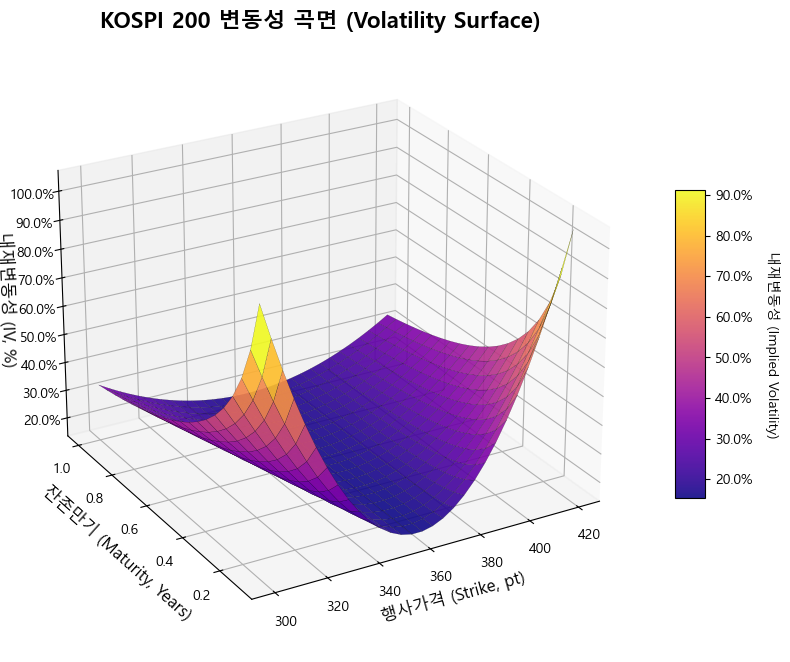

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import platform

# ==========================================
# [추가] Matplotlib 한글 깨짐 방지 폰트 설정
# ==========================================
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')   # 맥: 애플 고딕
else:
    # 리눅스 (코랩 등)에서는 폰트를 따로 설치해야 할 수 있습니다.
    plt.rc('font', family='NanumGothic')

# 마이너스 폰트 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
# ==========================================

# 1. 축 데이터 생성 (단위 명확화)
strikes = np.linspace(300, 420, 30)         # 행사가격 (단위: pt)
maturities = np.linspace(0.1, 1.0, 20)      # 잔존만기 (단위: 년, Year)

K_grid, T_grid = np.meshgrid(strikes, maturities)

# 2. 내재변동성(IV) 표면 시뮬레이션
S0 = 360.0 # 현재 기초자산 (pt)

# 기본 변동성 15% (0.15) 베이스에 스마일 및 기간구조 반영
IV_grid = 0.15 + 0.00005 * ((K_grid - S0) ** 2) / (T_grid + 0.1) + 0.02 * T_grid

# 3. 3D 시각화 세팅
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 곡면 그리기
surf = ax.plot_surface(K_grid, T_grid, IV_grid, cmap='plasma', 
                       edgecolor='k', linewidth=0.1, alpha=0.9)

# 타이틀 및 축 라벨 (단위 명시)
ax.set_title('KOSPI 200 변동성 곡면 (Volatility Surface)', fontsize=16, fontweight='bold')
ax.set_xlabel('행사가격 (Strike, pt)', fontsize=12)
ax.set_ylabel('잔존만기 (Maturity, Years)', fontsize=12)
ax.set_zlabel('내재변동성 (IV, %)', fontsize=12)

# Z축(변동성) 표기 방식을 소수점(0.15)에서 백분율(15%)로 포맷팅
from matplotlib.ticker import FuncFormatter
ax.zaxis.set_major_formatter(FuncFormatter(lambda z, _: f'{z*100:.1f}%'))

# 컬러바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('내재변동성 (Implied Volatility)', rotation=270, labelpad=20)
cbar.formatter = FuncFormatter(lambda z, _: f'{z*100:.1f}%')
cbar.update_ticks()

# 시점 조절
ax.view_init(elev=25, azim=-120)

plt.show()